In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Using -q (quiet) to avoid printing thousands of lines of file names
!unzip -q "/content/drive/MyDrive/Flickr8k.zip" -d /content

In [4]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm


# =============================================================================
# 1. Vision Transformer (Image Encoder)
#    Paper §2.4: "We experiment with the recently introduced Vision Transformer
#    (ViT) ... adding an additional layer normalization to the combined patch
#    and position embeddings before the transformer."
# =============================================================================

class PatchEmbedding(nn.Module):
    """Split image into patches and project to embedding dimension."""

    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=256):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size, stride=patch_size
        )

    def forward(self, x):
        # x: [B, C, H, W] → [B, embed_dim, H/P, W/P] → [B, num_patches, embed_dim]
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class VisionTransformer(nn.Module):
    """
    ViT image encoder as described in the CLIP paper.

    Key details from §2.4:
    - Patch + position embeddings with an EXTRA LayerNorm before transformer
    - [CLS] token for global representation
    - Final LayerNorm on the [CLS] output
    """

    def __init__(
        self,
        img_size=224,
        patch_size=16,
        in_channels=3,
        embed_dim=256,
        depth=6,
        num_heads=4,
        mlp_ratio=4.0,
        dropout=0.0,
    ):
        super().__init__()
        self.embed_dim = embed_dim

        # Patch embedding
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches

        # [CLS] token and positional embeddings
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim) * 0.02)

        # Paper §2.4: "adding an additional layer normalization to the combined
        # patch and position embeddings before the transformer"
        self.pre_norm = nn.LayerNorm(embed_dim)

        # Transformer encoder blocks
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,  # Pre-norm architecture
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        # Final layer norm
        self.ln_post = nn.LayerNorm(embed_dim)

    def forward(self, x):
        B = x.shape[0]

        # Patch embed: [B, num_patches, embed_dim]
        x = self.patch_embed(x)

        # Prepend [CLS] token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)

        # Add positional embeddings
        x = x + self.pos_embed

        # Paper-specified extra LayerNorm before transformer
        x = self.pre_norm(x)

        # Transformer
        x = self.transformer(x)

        # Extract [CLS] token representation
        x = x[:, 0]
        x = self.ln_post(x)

        return x  # [B, embed_dim]


# =============================================================================
# 2. Text Encoder (Transformer)
#    Paper §2.4: "The text encoder is a Transformer with the architecture
#    modifications described in Radford et al. (2019) [GPT-2]."
#    - Masked (causal) self-attention
#    - BPE tokenization, max 76 tokens
#    - [EOS] token activation as feature representation
#    - LayerNorm → linear projection into embedding space
# =============================================================================

class TextEncoder(nn.Module):
    """
    GPT-2-style causal Transformer text encoder.

    Paper §2.4: "Masked self-attention was used in the text encoder to
    preserve the ability to initialize with a pre-trained language model."

    The activations at the [EOS] token (= last non-padding token) from the
    highest layer serve as the text feature representation, which is layer
    normalized and then linearly projected.
    """

    def __init__(
        self,
        vocab_size=30522,       # HuggingFace bert-base-uncased vocab
        max_seq_len=76,         # Paper: "max sequence length was capped at 76"
        embed_dim=256,
        depth=4,
        num_heads=4,
        mlp_ratio=4.0,
        dropout=0.0,
    ):
        super().__init__()
        self.embed_dim = embed_dim
        self.max_seq_len = max_seq_len

        # Token and position embeddings
        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        self.position_embedding = nn.Embedding(max_seq_len, embed_dim)

        # Transformer with CAUSAL (masked) self-attention
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        # Final LayerNorm (applied to [EOS] token representation)
        self.ln_final = nn.LayerNorm(embed_dim)

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.token_embedding.weight, std=0.02)
        nn.init.normal_(self.position_embedding.weight, std=0.01)

    def forward(self, input_ids, attention_mask=None):
        """
        Args:
            input_ids:      [B, seq_len] token IDs
            attention_mask:  [B, seq_len] 1 for real tokens, 0 for padding
        Returns:
            text features:   [B, embed_dim]
        """
        B, seq_len = input_ids.shape
        device = input_ids.device

        # Token + positional embeddings
        positions = torch.arange(seq_len, device=device).unsqueeze(0)
        x = self.token_embedding(input_ids) + self.position_embedding(positions)

        # Causal mask: upper-triangular = masked (paper uses masked self-attention)
        causal_mask = torch.triu(
          torch.ones(seq_len, seq_len, dtype=torch.bool, device=device),
          diagonal=1
      )

        # Padding mask: True = ignore
        if attention_mask is not None:
            padding_mask = (attention_mask == 0)
        else:
            padding_mask = None

        x = self.transformer(x, mask=causal_mask, src_key_padding_mask=padding_mask)

        x = self.ln_final(x)

        # Paper §2.4: "the activations of the highest layer of the transformer
        # at the [EOS] token are treated as the feature representation of the text"
        # For BERT-style tokenizers, [EOS] = [SEP] = last real token
        if attention_mask is not None:
            # Index of last non-padding token per sequence
            eos_indices = attention_mask.sum(dim=1) - 1  # [B]
        else:
            eos_indices = torch.full((B,), seq_len - 1, device=device)

        # Gather [EOS] token features: [B, embed_dim]
        x = x[torch.arange(B, device=device), eos_indices, :]

        return x

In [7]:
# =============================================================================
# 3. CLIP Model
#    Paper §2.3: "We use only a linear projection to map from each encoder's
#    representation to the multi-modal embedding space."
#    "the temperature parameter τ is directly optimized during training as a
#    log-parameterized multiplicative scalar"
# =============================================================================

class CLIP(nn.Module):
    """
    Full CLIP model combining image and text encoders with learned
    linear projections and a learned temperature parameter.

    Follows the pseudocode from Figure 3 of the paper:
        I_e = l2_normalize(I_f @ W_i)
        T_e = l2_normalize(T_f @ W_t)
        logits = I_e @ T_e.T * exp(t)
        loss = symmetric_cross_entropy(logits)
    """

    def __init__(
        self,
        # Vision
        img_size=224,
        patch_size=16,
        vision_dim=256,
        vision_depth=6,
        vision_heads=4,
        # Text
        vocab_size=30522,
        max_seq_len=76,
        text_dim=256,
        text_depth=4,
        text_heads=4,
        # Shared
        embed_dim=256,
        init_temperature=0.07,
        max_temperature=100.0,
    ):
        super().__init__()

        # --- Encoders ---
        self.image_encoder = VisionTransformer(
            img_size=img_size,
            patch_size=patch_size,
            embed_dim=vision_dim,
            depth=vision_depth,
            num_heads=vision_heads,
        )
        self.text_encoder = TextEncoder(
            vocab_size=vocab_size,
            max_seq_len=max_seq_len,
            embed_dim=text_dim,
            depth=text_depth,
            num_heads=text_heads,
        )

        # --- Linear projections into shared embedding space ---
        # Paper §2.3: "We use only a linear projection"
        self.image_projection = nn.Linear(vision_dim, embed_dim, bias=False)
        self.text_projection = nn.Linear(text_dim, embed_dim, bias=False)

        # --- Learned temperature ---
        # Paper §2.5: "directly optimized during training as a
        # log-parameterized multiplicative scalar"
        # initialized to equivalent of τ = 0.07 → log(1/0.07) ≈ 2.6593
        self.log_temperature = nn.Parameter(
            torch.tensor(math.log(1.0 / init_temperature))
        )
        self.max_temperature = max_temperature

    def encode_image(self, images):
        """Encode images → L2-normalized embeddings."""
        features = self.image_encoder(images)                  # [B, vision_dim]
        embeddings = self.image_projection(features)           # [B, embed_dim]
        embeddings = F.normalize(embeddings, p=2, dim=-1)      # L2 normalize
        return embeddings

    def encode_text(self, input_ids, attention_mask=None):
        """Encode text → L2-normalized embeddings."""
        features = self.text_encoder(input_ids, attention_mask)  # [B, text_dim]
        embeddings = self.text_projection(features)              # [B, embed_dim]
        embeddings = F.normalize(embeddings, p=2, dim=-1)        # L2 normalize
        return embeddings

    def forward(self, images, input_ids, attention_mask=None):
        """
        Compute CLIP contrastive loss (Figure 3 pseudocode).

        Returns:
            loss: scalar, symmetric cross-entropy over similarity matrix
            logits_per_image: [B, B] similarity scores (image→text)
            logits_per_text:  [B, B] similarity scores (text→image)
        """
        # Encode both modalities
        image_embeddings = self.encode_image(images)       # [B, embed_dim]
        text_embeddings = self.encode_text(input_ids, attention_mask)  # [B, embed_dim]

        # Clamp temperature (paper §2.5: "clipped to prevent scaling
        # the logits by more than 100")
        temperature = torch.clamp(self.log_temperature, max=math.log(self.max_temperature))
        temperature = torch.exp(temperature)

        # Scaled pairwise cosine similarities: [B, B]
        logits_per_image = image_embeddings @ text_embeddings.T * temperature
        logits_per_text = logits_per_image.T

        # Symmetric cross-entropy loss
        B = images.shape[0]
        labels = torch.arange(B, device=images.device)
        loss_i = F.cross_entropy(logits_per_image, labels)
        loss_t = F.cross_entropy(logits_per_text, labels)
        loss = (loss_i + loss_t) / 2.0

        return loss, logits_per_image, logits_per_text


In [5]:
import os
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

class Flickr8kDataset(Dataset):
    def __init__(self, image_dir, captions_file, tokenizer):
        self.image_dir = image_dir
        self.tokenizer = tokenizer

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        self.data = []
        with open(captions_file, 'r') as f:
            lines = f.readlines()[1:] # Skip header
            for line in lines:
                parts = line.strip().split(',')
                if len(parts) >= 2:
                    img_name = parts[0]
                    caption = ",".join(parts[1:])
                    self.data.append((img_name, caption))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name, caption = self.data[idx]

        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        tokens = self.tokenizer(
            caption,
            padding='max_length',
            truncation=True,
            max_length=76,
            return_tensors="pt"
        )

        return image, tokens['input_ids'].squeeze(0), tokens['attention_mask'].squeeze(0)

In [14]:
# =============================================================================
# 4. Training Script
# =============================================================================

def train_clip():
    import os
    import json
    import time
    from torch.utils.data import DataLoader
    from transformers import BertTokenizer

    # --- Hyperparameters (Mini CLIP for Flickr8k) ---
    config = {
        "img_size": 224,
        "patch_size": 16,
        "vision_dim": 256,
        "vision_depth": 6,
        "vision_heads": 4,
        "text_dim": 256,
        "text_depth": 4,
        "text_heads": 4,
        "embed_dim": 256,
        "max_seq_len": 76,
        "batch_size": 128,
        "epochs": 30,
        "lr": 5e-4,
        "weight_decay": 0.2,        # Paper: decoupled weight decay
        "warmup_steps": 200,
        "init_temperature": 0.07,    # Paper §2.5
    }

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")
    print(f"Config: {json.dumps(config, indent=2)}")

    # --- Tokenizer ---
    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

    # --- Dataset ---
    # Adjust these paths to your Flickr8k location
    IMAGE_DIR = "/content/Flickr8k/Images"
    CAPTIONS_FILE = "/content/Flickr8k/captions.txt"


    dataset = Flickr8kDataset(IMAGE_DIR, CAPTIONS_FILE, tokenizer)
    dataloader = DataLoader(
        dataset, batch_size=config["batch_size"],
        shuffle=True, num_workers=4, pin_memory=True, drop_last=True
    )

    print(f"Dataset size: {len(dataset)} image-caption pairs")
    print(f"Batches per epoch: {len(dataloader)}")

    # --- Model ---
    model = CLIP(
        img_size=config["img_size"],
        patch_size=config["patch_size"],
        vision_dim=config["vision_dim"],
        vision_depth=config["vision_depth"],
        vision_heads=config["vision_heads"],
        vocab_size=tokenizer.vocab_size,
        max_seq_len=config["max_seq_len"],
        text_dim=config["text_dim"],
        text_depth=config["text_depth"],
        text_heads=config["text_heads"],
        embed_dim=config["embed_dim"],
        init_temperature=config["init_temperature"],
    ).to(device)

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    # --- Optimizer: AdamW (paper §2.5: Adam + decoupled weight decay) ---
    # Paper: "applied to all weights that are not gains or biases"
    decay_params = []
    no_decay_params = []
    for name, param in model.named_parameters():
        if param.requires_grad:
            if param.ndim < 2 or "bias" in name or "ln" in name or "norm" in name:
                no_decay_params.append(param)
            else:
                decay_params.append(param)

    optimizer = torch.optim.AdamW([
        {"params": decay_params, "weight_decay": config["weight_decay"]},
        {"params": no_decay_params, "weight_decay": 0.0},
    ], lr=config["lr"], betas=(0.9, 0.98), eps=1e-6)

    # --- LR Schedule: cosine decay with warmup (paper §2.5) ---
    total_steps = config["epochs"] * len(dataloader)
    warmup_steps = config["warmup_steps"]

    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    # --- Training loop ---
    history = {"epoch": [], "loss": [], "temperature": [], "lr": []}

    print("\n" + "=" * 60)
    print("Starting Mini CLIP Training")
    print("=" * 60)

    for epoch in range(config["epochs"]):
      model.train()
      epoch_loss = 0.0
      t0 = time.time()

      pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{config['epochs']}", leave=True)
      for batch_idx, (images, input_ids, attention_mask) in enumerate(pbar):
          images = images.to(device)
          input_ids = input_ids.to(device)
          attention_mask = attention_mask.to(device)

          loss, _, _ = model(images, input_ids, attention_mask)

          optimizer.zero_grad()
          loss.backward()

          torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

          optimizer.step()
          scheduler.step()

          epoch_loss += loss.item()
          pbar.set_postfix(loss=f"{loss.item():.4f}", τ=f"{torch.exp(model.log_temperature).item():.2f}")

      avg_loss = epoch_loss / len(dataloader)
      current_temp = torch.exp(model.log_temperature).item()
      current_lr = scheduler.get_last_lr()[0]
      elapsed = time.time() - t0

      history["epoch"].append(epoch + 1)
      history["loss"].append(avg_loss)
      history["temperature"].append(current_temp)
      history["lr"].append(current_lr)

      print(
          f"Epoch {epoch+1:3d}/{config['epochs']} │ "
          f"Loss: {avg_loss:.4f} │ "
          f"τ: {current_temp:.4f} │ "
          f"LR: {current_lr:.6f} │ "
          f"Time: {elapsed:.1f}s"
      )

    # --- Save model + training history ---
    save_dir = "/content"
    torch.save(model.state_dict(), os.path.join(save_dir, "mini_clip.pt"))
    with open(os.path.join(save_dir, "training_history.json"), "w") as f:
        json.dump(history, f)

    print("\n" + "=" * 60)
    print(f"Training complete! Model saved to {save_dir}/mini_clip.pt")
    print(f"Final loss: {history['loss'][-1]:.4f}")
    print(f"Final temperature: {history['temperature'][-1]:.4f}")
    print("=" * 60)

    return model, history

In [15]:
model, history = train_clip()

Device: cuda
Config: {
  "img_size": 224,
  "patch_size": 16,
  "vision_dim": 256,
  "vision_depth": 6,
  "vision_heads": 4,
  "text_dim": 256,
  "text_depth": 4,
  "text_heads": 4,
  "embed_dim": 256,
  "max_seq_len": 76,
  "batch_size": 128,
  "epochs": 30,
  "lr": 0.0005,
  "weight_decay": 0.2,
  "warmup_steps": 200,
  "init_temperature": 0.07
}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_1275/3046450847.py:80: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
/tmp/ipykernel_1275/3046450847.py:161: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)


Dataset size: 40455 image-caption pairs
Batches per epoch: 316
Total parameters: 16,110,849
Trainable parameters: 16,110,849

Starting Mini CLIP Training


Epoch 1/30:   0%|          | 0/316 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(
Epoch 1/30: 100%|██████████| 316/316 [04:13<00:00,  1.25it/s, loss=4.0223, τ=14.06]


Epoch   1/30 │ Loss: 4.4275 │ τ: 14.0612 │ LR: 0.000500 │ Time: 253.6s


...

Epoch  28/30 │ Loss: 0.0342 │ τ: 39.6364 │ LR: 0.000006 │ Time: 256.7s


Epoch 29/30: 100%|██████████| 316/316 [04:17<00:00,  1.23it/s, loss=0.0323, τ=39.67]


Epoch  29/30 │ Loss: 0.0311 │ τ: 39.6723 │ LR: 0.000001 │ Time: 257.3s


Epoch 30/30: 100%|██████████| 316/316 [04:14<00:00,  1.24it/s, loss=0.0387, τ=39.68]


Epoch  30/30 │ Loss: 0.0321 │ τ: 39.6776 │ LR: 0.000000 │ Time: 254.7s

Training complete! Model saved to /content/mini_clip.pt
Final loss: 0.0321
Final temperature: 39.6776


In [8]:
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from transformers import BertTokenizer

# ---- Setup ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

config = {
        "img_size": 224,
        "patch_size": 16,
        "vision_dim": 256,
        "vision_depth": 6,
        "vision_heads": 4,
        "text_dim": 256,
        "text_depth": 4,
        "text_heads": 4,
        "embed_dim": 256,
        "max_seq_len": 76,
        "batch_size": 128,
        "epochs": 30,
        "lr": 5e-4,
        "weight_decay": 0.2,
        "warmup_steps": 200,
        "init_temperature": 0.07,
    }

model = CLIP(
        img_size=config["img_size"],
        patch_size=config["patch_size"],
        vision_dim=config["vision_dim"],
        vision_depth=config["vision_depth"],
        vision_heads=config["vision_heads"],
        vocab_size=tokenizer.vocab_size,
        max_seq_len=config["max_seq_len"],
        text_dim=config["text_dim"],
        text_depth=config["text_depth"],
        text_heads=config["text_heads"],
        embed_dim=config["embed_dim"],
        init_temperature=config["init_temperature"],
    ).to(device)

model.load_state_dict(torch.load("/content/mini_clip.pt", map_location=device))
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

/tmp/ipykernel_383/1595575627.py:80: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
/tmp/ipykernel_383/1595575627.py:161: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)


In [25]:
image = Image.open("/content/GOPR0180.JPG").convert("RGB")
image_tensor = transform(image).unsqueeze(0).to(device)  # [1, 3, 224, 224]

captions = [
    "a man poses in snow covered mountains",
    "a cat sleeping on a sofa",
    "a bird flying over the ocean",
]

# Tokenize all 5 captions
tokens = tokenizer(
    captions, padding='max_length', truncation=True,
    max_length=76, return_tensors="pt"
)
input_ids = tokens['input_ids'].to(device)          # [5, 76]
attention_mask = tokens['attention_mask'].to(device) # [5, 76]

with torch.no_grad():
    image_emb = model.encode_image(image_tensor)                  # [1, 256]
    text_emb = model.encode_text(input_ids, attention_mask)       # [5, 256]
    similarities = (image_emb @ text_emb.T).squeeze(0)            # [5]
    probs = F.softmax(similarities * torch.exp(model.log_temperature), dim=0)

print("=== Image → Best Caption ===")
for i, caption in enumerate(captions):
    print(f"  {probs[i].item()*100:5.1f}%  {caption}")
print(f"  Best: {captions[probs.argmax()]}")

=== Image → Best Caption ===
   16.5%  a man poses in snow covered mountains
   14.5%  a cat sleeping on a sofa
   69.0%  a bird flying over the ocean
  Best: a bird flying over the ocean



=== Caption → Best Image ===
  Caption: 'a man in snow'
  100.0%  /content/GOPR0126.JPG
    0.0%  /content/GOPR0180.JPG
  Best: /content/GOPR0126.JPG


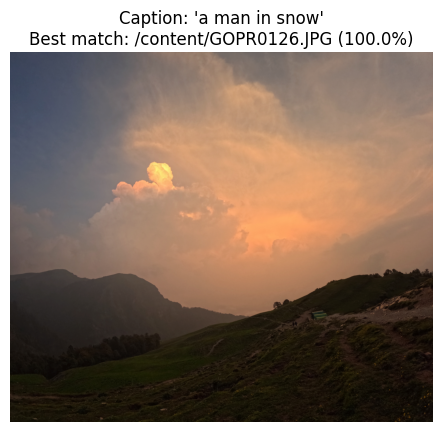

In [22]:
image_paths = [
    "/content/GOPR0126.JPG",
    "/content/GOPR0180.JPG",
]

# Load and stack all 5 images
images = []
for path in image_paths:
    img = Image.open(path).convert("RGB")
    images.append(transform(img))
image_batch = torch.stack(images).to(device)  # [5, 3, 224, 224]

caption = "a man in snow"
tokens = tokenizer(
    caption, padding='max_length', truncation=True,
    max_length=76, return_tensors="pt"
)
input_ids = tokens['input_ids'].to(device)          # [1, 76]
attention_mask = tokens['attention_mask'].to(device) # [1, 76]

with torch.no_grad():
    image_emb = model.encode_image(image_batch)                   # [5, 256]
    text_emb = model.encode_text(input_ids, attention_mask)       # [1, 256]
    similarities = (text_emb @ image_emb.T).squeeze(0)            # [5]
    probs = F.softmax(similarities * torch.exp(model.log_temperature), dim=0)

print("\n=== Caption → Best Image ===")
print(f"  Caption: '{caption}'")
for i, path in enumerate(image_paths):
    print(f"  {probs[i].item()*100:5.1f}%  {path}")
print(f"  Best: {image_paths[probs.argmax()]}")

img = Image.open(image_paths[probs.argmax()]).convert("RGB")
plt.imshow(img)
plt.title(f"Caption: '{caption}'\nBest match: {image_paths[best_idx]} ({probs[best_idx].item()*100:.1f}%)")
plt.axis("off")
plt.show()

